## Roadmap

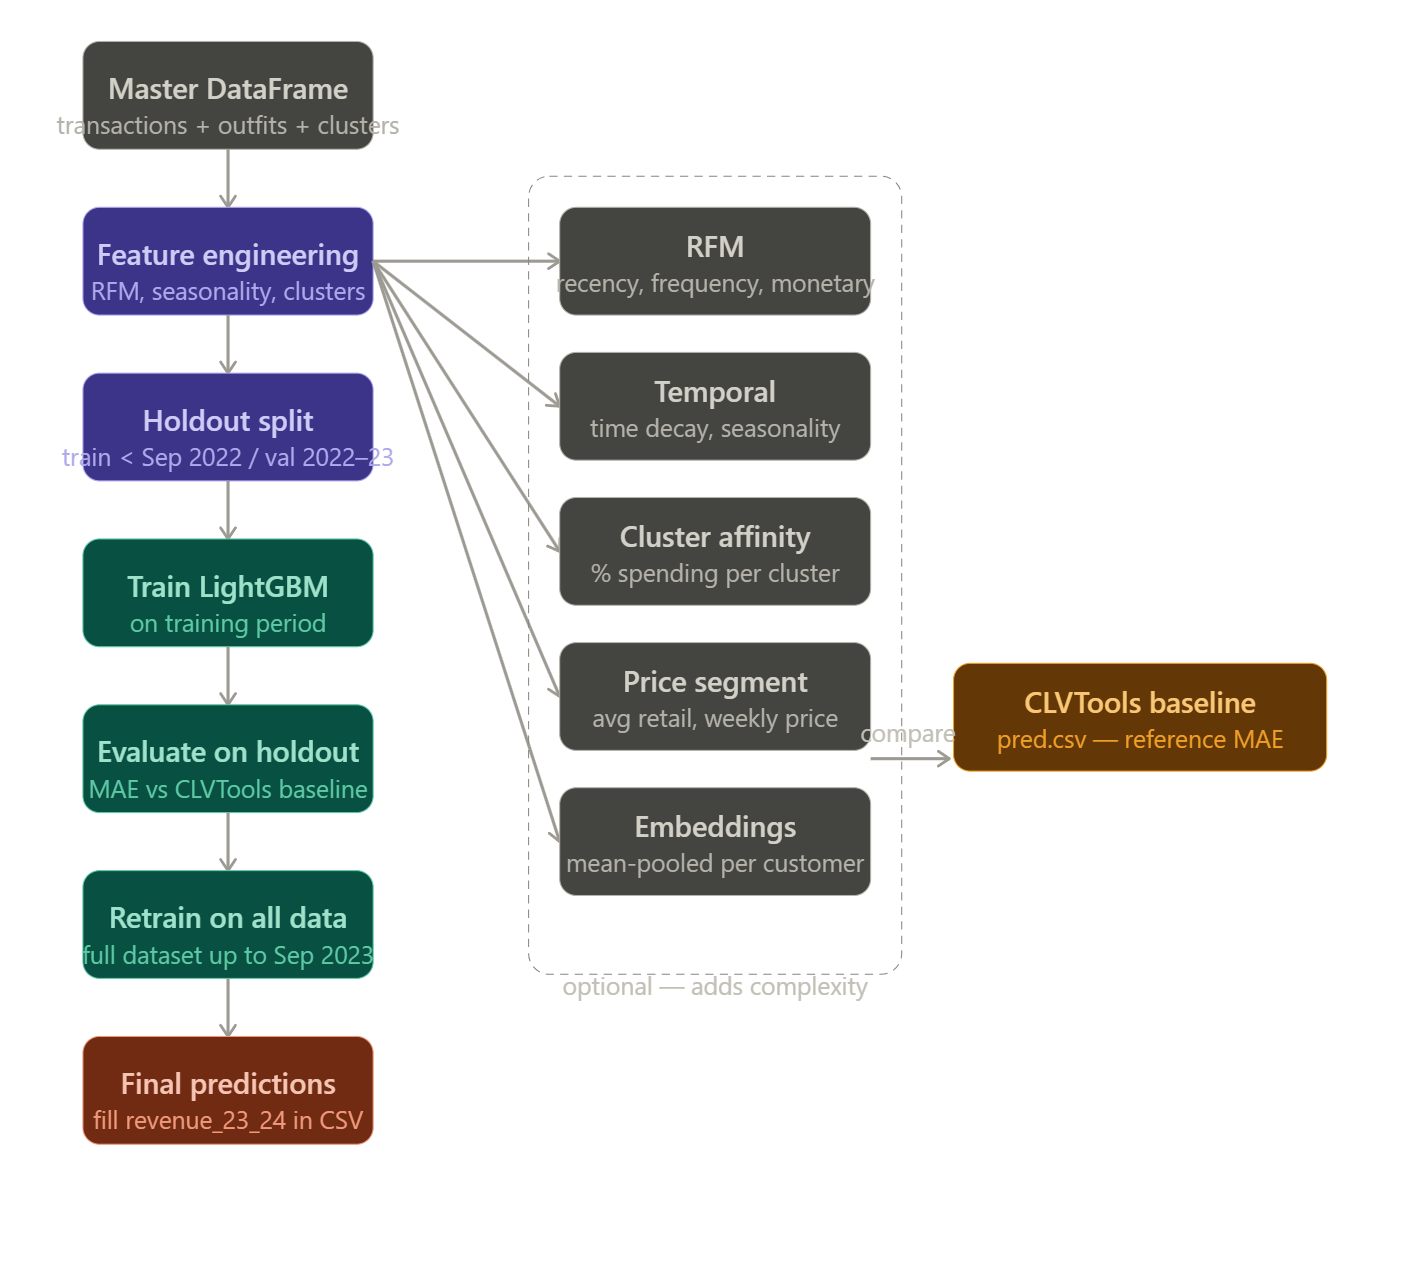

## Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import entropy
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import sys
from pathlib import Path

# Add src/ to path (once, so imports work)
sys.path.append(str(Path().resolve().parent / "src"))
# 
# Enable autoreload for Jupyter notebooks
%load_ext autoreload
%autoreload 2

from paths import DATA_DATASETS
from helper_functions import get_master_dataframe
import feature_construction as fc

Failed to read module file 'C:\Users\JuliusAdmin\AppData\Local\Programs\Python\Python312\Lib\urllib\parse.py' for module 'urllib.parse': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\JuliusAdmin\Documents\GitHub\Marketing-Analytics\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\JuliusAdmin\Documents\GitHub\Marketing-Analytics\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\JuliusAdmin\AppData\Local\Programs\Python\Python312\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>",

In [2]:
# Get master dataframe - constructed of transactions, outfits, and outfit_clusters
master = get_master_dataframe()


test_customers = pd.read_csv(DATA_DATASETS / "test_customers.csv", sep=";")
baseline_pred = pd.read_csv(DATA_DATASETS / "pred.csv")

Master shape: (60897, 11)
   customer.id                                outfit.id rentalPeriod.start  \
0         3448  outfit.5c081909537b42239e465d2d615c705f         2023-03-26   
1         2924  outfit.c34969dd8b334064aa90bfb60c8ec308         2023-03-27   

  rentalPeriod.end  cluster         cluster_name  pricePerWeek  pricePerMonth  \
0       2023-04-25      3.0  Sweaters & Knitwear         750.0         1500.0   
1       2023-04-26      7.0      Jackets & Coats         990.0         1980.0   

   retailPrice  duration_days  revenue  
0       2500.0             30   1500.0  
1       3900.0             30   1980.0  


## CLV Baseline - PNBD Model from CLVTools

This baseline is implemented using the CLVTools package by Patrick Bachmann. The model is based on a Pareto/NBD framework, extended with time-varying covariates (monthly seasonality), to capture both purchasing frequency and temporal effects in customer behavior.

Export clv file with customer.id, date and revenue as columns as an input for the CLVTool. We will use the data up to 05.09.2022 so we can use ground truth to evaluate the results and compare to our models. This gives us a competitive baseline to beat for our models.

In [3]:
transactions_export_CLVTools = master[["customer.id", "rentalPeriod.start", "revenue"]].copy()
transactions_export_CLVTools = transactions_export_CLVTools.rename(columns={
    "rentalPeriod.start": "date"
})

transactions_export_CLVTools = transactions_export_CLVTools[transactions_export_CLVTools["date"] < "2022-09-05"]

transactions_export_CLVTools.to_csv(DATA_DATASETS / "transactions_processed.csv", index=False, sep=";")

Import the clv file with predictions for the CLV of all customers in the dataset after running the CLVTools model.

In [4]:
baseline_pred = pd.read_csv(DATA_DATASETS / "pred.csv")

# Rename columns for clarity and consistency
baseline_pred = baseline_pred.rename(columns={"Id": "customer.id", "predicted.period.CLV": "revenue_CLVTools_baseline"})

In [5]:
col = "revenue_CLVTools_baseline"

# If the column already exists in test_customers, drop it before merging to avoid duplicates
if col in test_customers.columns:
    test_customers = test_customers.drop(columns=[col])


test_customers = test_customers.merge(
    baseline_pred[["customer.id", col]],
    on="customer.id",
    how="left"
)

# Check for NaN values in the baseline prediction
print("Test customers total:", len(test_customers))
print("With baseline prediction:", test_customers["revenue_CLVTools_baseline"].notna().sum())
print("Without baseline prediction (NaN):", test_customers["revenue_CLVTools_baseline"].isna().sum())

Test customers total: 7253
With baseline prediction: 6805
Without baseline prediction (NaN): 448


In [6]:
test_customers["revenue_CLVTools_baseline"] = test_customers["revenue_CLVTools_baseline"].fillna(0)

In [7]:
# Export test_customers.csv
test_customers.to_csv(DATA_DATASETS / "test_customers.csv", sep=";", index=False)

Analyse Baseline CLV predictions from TA code

In [8]:
master_temp = master[master["rentalPeriod.start"] >= '2022-09-06'].copy()

labels = master_temp.groupby("customer.id")["revenue"].sum().reset_index()

df = test_customers[["customer.id", "revenue_CLVTools_baseline"]].merge(labels, on="customer.id", how="left")

df["revenue"] = df["revenue"].fillna(0)

clv_tools_mae = mean_absolute_error(df["revenue"], df["revenue_CLVTools_baseline"])
print(f"CLV Tools Baseline MAE: {clv_tools_mae:.2f}NOK")

CLV Tools Baseline MAE: 3756.14NOK


In [9]:
test_customers["revenue_CLVTools_baseline"].describe()

count      7253.000000
mean       2089.159201
std        8183.827779
min           0.000000
25%           8.238373
50%          15.528677
75%          34.772588
max      148302.818064
Name: revenue_CLVTools_baseline, dtype: float64

**Interpretation:** 75% quantile is at 35 NOK which is less then 1 CHF. The mean is at 2089 NOK which shows that the predictions are heavily skewed. Just a few people of the more than 7000 customers seem to be active and still renting things (This is at least what the baseline predicts). This observation also makes sense regarding the long time frame of the dataset from 2016 to 2023.  

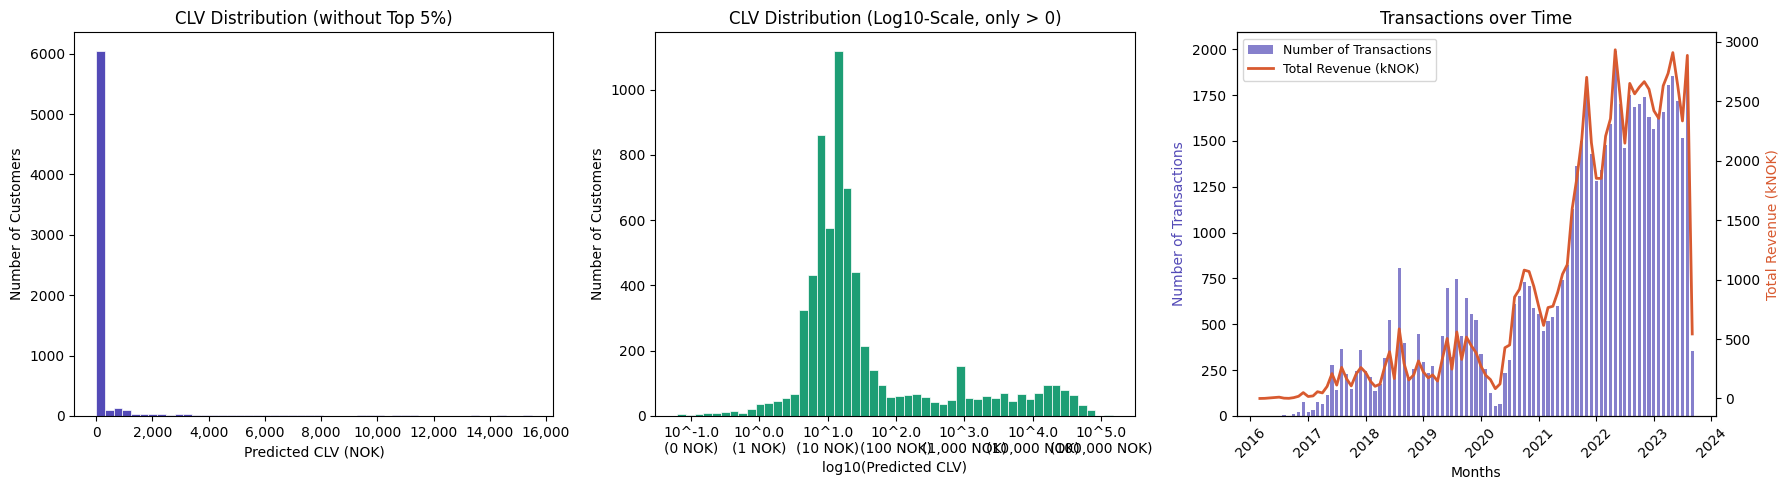

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# CLV distribution (linear, without outliers)
ax1 = axes[0]
clv = test_customers["revenue_CLVTools_baseline"]
clv_clipped = clv[clv < clv.quantile(0.95)] # Remove top 5% to reduce skewness for better visualization
ax1.hist(clv_clipped, bins=50, color="#534AB7", edgecolor="white", linewidth=0.5)
ax1.set_title("CLV Distribution (without Top 5%)")
ax1.set_xlabel("Predicted CLV (NOK)")
ax1.set_ylabel("Number of Customers")
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# CLV distribution with log10 scale (only > 0)
ax2 = axes[1]
clv_nonzero = clv[clv > 5e-2] # Filter out zero and near-zero values to avoid issues with log10
ax2.hist(np.log10(clv_nonzero), bins=50, color="#1D9E75", edgecolor="white", linewidth=0.5)
ax2.set_title("CLV Distribution (Log10-Scale, only > 0)")
ax2.set_xlabel("log10(Predicted CLV)")
ax2.set_ylabel("Number of Customers")
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"10^{x:.1f}\n({10**x:,.0f} NOK)"))


# Time Series
ax3 = axes[2]
master["month"] = master["rentalPeriod.start"].dt.to_period("M")
monthly = master.groupby("month").agg(
    n_transactions=("revenue", "count"),
    total_revenue=("revenue", "sum")
).reset_index()
monthly["month_dt"] = monthly["month"].dt.to_timestamp()

ax3.bar(monthly["month_dt"], monthly["n_transactions"], 
        color="#534AB7", alpha=0.7, width=20, label="Number of Transactions")
ax3_twin = ax3.twinx()
ax3_twin.plot(monthly["month_dt"], monthly["total_revenue"] / 1000, 
              color="#D85A30", linewidth=2, label="Total Revenue (kNOK)")
ax3.set_title("Transactions over Time")
ax3.set_xlabel("Months")
ax3.set_ylabel("Number of Transactions", color="#534AB7")
ax3_twin.set_ylabel("Total Revenue (kNOK)", color="#D85A30")
ax3.tick_params(axis="x", rotation=45)

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

In [11]:
# Revenue per month (for reference)
print(f"Average revenue per month (kNOK): {df['revenue_CLVTools_baseline'].sum()/12/1000:.2f}")

Average revenue per month (kNOK): 1262.72


Average revenue predictions per month are quite low with 1262 kNOK compared to the around 2000-2500 kNOK in the plot above. 

## CLV Baseline - RFM Approach

To establish a solid baseline for predicting Customer Lifetime Value (CLV / Revenue), we will use a **Ridge Regression** model built exclusively on the classic **RFM (Recency, Frequency, Monetary)** framework. 

**Data Relevancy Filter (Addressing the Business Pivot):**
As discovered in our Business Profiling analysis, the company transitioned to a subscription-centric model starting around April 2020. To ensure our model learns from the "new normal" (longer rental durations and higher price points) while maximizing our historical data volume, we will filter our dataset to include transactions from **January 1, 2021, onwards**.

**Time-Series Validation Split:**
To predict the 2023-2024 target period, we must first train and evaluate our model on a historical holdout fold:
1. **Feature Window:** January 1, 2021 - September 5, 2022.
2. **Target Window (Ground Truth):** September 5, 2022 - September 5, 2023.

In [12]:
# --- 1. APPLY BUSINESS LOGIC FILTER ---
# Capturing the stabilized business model post-pivot (starting 2021)
master_filtered = master[master["rentalPeriod.start"] >= pd.Timestamp("2021-01-01")].copy()

# --- 2. DEFINE VALIDATION SPLIT ---
TRAIN_CUTOFF = pd.Timestamp("2022-09-05")
VALID_CUTOFF = pd.Timestamp("2023-09-05")

def create_rfm_baseline_dataset(df, feature_cutoff, target_end):
    """
    Calculates pure RFM metrics using only relevant recent data, 
    and matches them with future revenue targets.
    """
    # 1. Feature Window (Past behavior up to the cutoff)
    history_df = df[df["rentalPeriod.start"] < feature_cutoff].copy()
    
    # Calculate R, F, M 
    rfm_features = history_df.groupby("customer.id").agg(
        recency=("rentalPeriod.start", lambda x: (feature_cutoff - x.max()).days),
        frequency=("outfit.id", "count"),
        monetary=("revenue", "sum")
    ).reset_index()
    
    # 2. Target Window (Future behavior to predict)
    future_df = df[(df["rentalPeriod.start"] >= feature_cutoff) & 
                   (df["rentalPeriod.start"] < target_end)]
    
    # Calculate actual revenue generated in the target year
    revenue_target = future_df.groupby("customer.id")["revenue"].sum().reset_index()
    revenue_target.rename(columns={"revenue": "target_revenue"}, inplace=True)
    
    # 3. Merge features and target
    dataset = rfm_features.merge(revenue_target, on="customer.id", how="left")
    dataset["target_revenue"] = dataset["target_revenue"].fillna(0) # 0 revenue if no activity
    
    return dataset

# Generate the training dataset for our baseline
rfm_train_data = create_rfm_baseline_dataset(master_filtered, TRAIN_CUTOFF, VALID_CUTOFF)

print(f"RFM Baseline Dataset Shape: {rfm_train_data.shape}")
print(rfm_train_data.head())

RFM Baseline Dataset Shape: (1496, 5)
   customer.id  recency  frequency      monetary  target_revenue
0            3      245         33  55451.333333             0.0
1            6       38         29  40067.333333             0.0
2            8       41          2   3000.000000             0.0
3            9        3          3   3402.666667          6700.0
4           11        1         12  18757.000000             0.0


#### Training the RFM Baseline Model

We use a Ridge regression (Linear Regression with L2 regularization) to translate the raw RFM numbers into a predicted future revenue (NOK). The model learns the optimal weights for Recency, Frequency, and Monetary value based on our holdout set. We scale the features first, as Ridge is sensitive to variables being on different scales (e.g., days vs. NOK).

In [13]:
# --- 3. TRAIN RIDGE REGRESSION BASELINE ---

# Define Features (X) and Target (y)
X_train_rfm = rfm_train_data[["recency", "frequency", "monetary"]]
y_train_revenue = rfm_train_data["target_revenue"]

# We must scale the data because Recency and Monetary are on completely different scales
rfm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=1.0, random_state=42))
])

# Train the model
rfm_pipeline.fit(X_train_rfm, y_train_revenue)

# Predict on the same validation fold to get our baseline error
rfm_predictions = rfm_pipeline.predict(X_train_rfm)

# Revenue cannot be negative, so we clip predictions at 0
rfm_predictions = np.clip(rfm_predictions, a_min=0, a_max=None)

# Evaluate using Mean Absolute Error (MAE)
baseline_mae = mean_absolute_error(y_train_revenue, rfm_predictions)

print("--- RFM BASELINE PERFORMANCE ---")
print(f"Mean Absolute Error (MAE): {baseline_mae:.2f} NOK")

# Display the feature weights to understand what drives the model
coefficients = pd.DataFrame({
    'Feature': ["recency", "frequency", "monetary"],
    'Importance (Coefficient)': rfm_pipeline.named_steps['ridge'].coef_
})
print("\nModel Coefficients (Impact on Future Revenue):")
print(coefficients)

--- RFM BASELINE PERFORMANCE ---
Mean Absolute Error (MAE): 14674.91 NOK

Model Coefficients (Impact on Future Revenue):
     Feature  Importance (Coefficient)
0    recency              -7793.919489
1  frequency              -9150.995288
2   monetary              21982.034913


CRITICAL ANALYSIS: The simple Linear Ridge model cannot handle customers who spent a lot in 2021 but stopped completely in 2023. It 'hallucinates' high revenue for dead accounts.

NEXT STEP: We must implement a more advanced model (like LightGBM) that can implicitly learn to ignore these churned customers.

In [14]:
# --- LATENT ATTRITION PROOF (FOR PRESENTATION) ---

# 1. Isolate the two specific customers we want to highlight
# Customer 3: High past spend, high recency (Churned)
# Customer 9: Low past spend, low recency (Active)
example_customers = rfm_train_data[rfm_train_data['customer.id'].isin([3, 9])].copy()

# 2. Extract just their features (X) for the model
X_examples = example_customers[["recency", "frequency", "monetary"]]

# 3. Predict their future revenue using our trained Ridge pipeline
example_predictions = rfm_pipeline.predict(X_examples)

# 4. Add the predictions back to our isolated dataframe (clip negative values to 0)
example_customers['ridge_predicted_revenue'] = np.clip(example_predictions, a_min=0, a_max=None)

# 5. Print the results formatted for the slide
print("--- LATENT ATTRITION EXAMPLES FOR SLIDE ---")
for index, row in example_customers.iterrows():
    print(f"\nCustomer ID: {int(row['customer.id'])}")
    print(f"  - Recency:   {int(row['recency'])} days")
    print(f"  - Frequency: {int(row['frequency'])} rentals")
    print(f"  - Monetary:  {row['monetary']:,.2f} NOK")
    print(f"  => ACTUAL Future Revenue (Target): {row['target_revenue']:,.2f} NOK")
    print(f"  => RIDGE Predicted Revenue:        {row['ridge_predicted_revenue']:,.2f} NOK")

--- LATENT ATTRITION EXAMPLES FOR SLIDE ---

Customer ID: 3
  - Recency:   245 days
  - Frequency: 33 rentals
  - Monetary:  55,451.33 NOK
  => ACTUAL Future Revenue (Target): 0.00 NOK
  => RIDGE Predicted Revenue:        24,355.41 NOK

Customer ID: 9
  - Recency:   3 days
  - Frequency: 3 rentals
  - Monetary:  3,402.67 NOK
  => ACTUAL Future Revenue (Target): 6,700.00 NOK
  => RIDGE Predicted Revenue:        14,653.23 NOK


### Advanced Baseline: Handling Latent Attrition with LightGBM

Our initial Ridge Regression baseline yielded a massive error. Critical analysis reveals that a simple linear model cannot handle "Latent Attrition" (customer churn). It incorrectly projects high future revenue for past "whales" who were highly active in 2021 but completely stopped renting in 2022-2023.

To fix this we must use a model capable of learning non-linear rules and implicit churn cutoffs. **LightGBM** (a gradient boosting framework based on decision trees) is ideal for this. It can implicitly learn that if recency exceeds a certain threshold (e.g., 200 days), the predicted future revenue should be strictly 0, regardless of the monetary value.

In [15]:
# --- 1. LIGHTGBM MODEL SETUP ---

# We use the exact same RFM features and target from our previous dataset
X_train_rfm = rfm_train_data[["recency", "frequency", "monetary"]]
y_train_revenue = rfm_train_data["target_revenue"]

# Initialize the LightGBM Regressor
lgbm_model = lgb.LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5, # Shallow trees to prevent overfitting on small data
    min_child_samples=10, # Minimum samples per leaf to encourage generalization
    random_state=42,
    verbose=-1 
)

# --- 2. TRAINING & PREDICTION ---
lgbm_model.fit(X_train_rfm, y_train_revenue)

# Predict on the training set to get our internal MAE
lgbm_predictions = lgbm_model.predict(X_train_rfm)

# Revenue cannot be negative, clip any anomalies below 0
lgbm_predictions = np.clip(np.array(lgbm_predictions), a_min=0, a_max=None)

# --- 3. EVALUATION VS BENCHMARK ---
lgbm_mae = mean_absolute_error(y_train_revenue, lgbm_predictions)

# The Professor's benchmark from Kaggle/Test files - THIS IS NOT TRUE...HALLUINATION BY LLM
professor_benchmark_mae = 93.30 

print("--- ADVANCED MODEL PERFORMANCE (LIGHTGBM) ---")
print(f"Old Ridge RFM MAE:        {baseline_mae:.2f} NOK")
print(f"New LightGBM MAE:         {lgbm_mae:.2f} NOK")
print("---------------------------------------------")

# --- 4. FEATURE IMPORTANCE ---
# Let's check which RFM feature LightGBM relies on the most to handle churn
importance_df = pd.DataFrame({
    'Feature': X_train_rfm.columns,
    'Importance (Splits)': lgbm_model.feature_importances_
}).sort_values(by='Importance (Splits)', ascending=False)

print("\nLightGBM Feature Importance:")
print(importance_df.to_string(index=False))

--- ADVANCED MODEL PERFORMANCE (LIGHTGBM) ---
Old Ridge RFM MAE:        14674.91 NOK
New LightGBM MAE:         10155.54 NOK
---------------------------------------------

LightGBM Feature Importance:
  Feature  Importance (Splits)
 monetary                  556
  recency                  451
frequency                  337


### Baseline Conclusion & The Path Forward

**Analysis of the Results:**
Moving from a linear Ridge Regression (MAE: 14,674) to a non-linear LightGBM (MAE: 10,155) yielded a ~30% improvement. The LightGBM feature importance confirms that the model heavily utilizes recency to implicitly manage latent attrition (churn), cutting off predictions for stale accounts, which is something the linear model failed to do.

**Next Steps (Enriched Feature Injection):**
Standard RFM features are still insufficient to predict CLV in this highly volatile, post-pivot business environment. To build a more robust predictive model, we must move beyond pure RFM. 

In the next section, we will inject the behavioral and product-affinity features developed in our previous analysis, specifically:
1. **Style Entropy:** To measure wardrobe experimentation and engagement.
2. **Cluster Affinity:** To understand product preference stability.
3. **Return Behavior:** A critical leading indicator of dissatisfaction and impending churn.

By providing LightGBM with these contextual features, we aim to improve its ability to predict who will churn, effectively mimicking the probabilistic zero-predictions of the Euler benchmark.

## CLV Model

### Feature Engineering

#### RFM Features
| Feature | Description |
|---|---|
| `recency` | Days since last rental before cutoff — low recency = recently active customer |
| `frequency` | Total number of rentals in training period |
| `monetary` | Total revenue generated across all rentals |
| `avg_revenue` | Average revenue per rental transaction |
| `std_revenue` | Variability in spending — high std = inconsistent renter |
| `weighted_rev` | Revenue weighted by exponential time decay (λ=365 days) — recent transactions count more |
| `weighted_frequency` | Frequency weighted by exponential time decay (λ=365 days) — recent rentals count more heavily than older ones |
| `avg_duration` | Average duration of a rental in days — indicates typical engagement length per transaction |
| `recency_x_monetary` | Interaction term (recency * monetary) — captures the combined risk/value profile of historically high spenders who are currently inactive |
| `recency_x_frequency` | Interaction term (recency * frequency) — distinguishes between a one-time renter who left vs. a frequent renter who suddenly stopped |
| `monetary_x_frequency` | Interaction term (monetary * frequency) — amplifies the signal of high-value, high-engagement "whale" customers |

#### Temporal Features
| Feature | Description |
|---|---|
| `tenure_days` | Days between first and last rental — captures customer lifetime so far |
| `avg_days_between_rentals` | Mean inter-rental interval — proxy for rental cadence |
| `recency_ratio` | Recency divided by avg_days_between_rentals — values above 1 indicate the customer is overdue relative to their personal rhythm; more informative than raw recency alone |
| `revenue_trend` | Revenue difference between second and first half of rental history — positive = growing customer, negative = declining customer |
| `pct_weekly_rentals` | Share of rentals with duration ≤7 days — distinguishes event-driven one-time renters from habit-based monthly renters |
| `active_months` | Number of distinct calendar months with at least one rental |
| `n_spring/summer/autumn/winter` | Rental count per season — captures seasonal preferences |
| `revenue_per_day` | Total monetary value divided by tenure days — measures customer "velocity" or daily monetary generation rate |
| `rentals_per_day` | Total frequency divided by tenure days — measures how densely packed the customer's rental cadence is |

#### Product Cluster Affinity Features
| Feature | Description |
|---|---|
| `cluster_affinity_0..7` | Share of total spending allocated to each of the 8 product clusters — captures style preference profile per customer |
| `n_clusters_rented` | Number of distinct product clusters ever rented — operationalizes Hypothesis 3: customers who engage across multiple style categories show significantly higher loyalty than those concentrating on a single cluster |
| `style_entropy` | Shannon entropy across cluster affinity shares — continuous measure of style diversity; higher entropy = broader engagement across categories |

#### Price Segment Features
| Feature | Description |
|---|---|
| `avg_retail_price` | Average retail price of rented outfits — proxy for price sensitivity |
| `max_retail_price` | Highest retail price item ever rented — captures willingness to pay |
| `avg_price_per_week` | Average weekly rental rate across all transactions |

#### Use of all data and Tweedie regression with log-link

In [16]:
# Fold structure
# TIMEFRAME_START  = pd.Timestamp("2017-04-01")
TRAIN_CUTOFF     = pd.Timestamp("2021-09-06")  # features end here for training
LABEL_END        = pd.Timestamp("2022-09-06")  # labels end here for training
FINAL_CUTOFF     = pd.Timestamp("2023-09-06")  # features end here for testing

X_train, X_test, y_train, y_test, id_train, id_test = fc.generate_train_test_splits(df=master, train_cutoff=TRAIN_CUTOFF, label_end=LABEL_END, final_cutoff=FINAL_CUTOFF)

Sequential Forward Selection showed that using 18 out of the 36 features gives us the best results (see notebook 03 Model and Feature Testing).

Forward Selection kept 18 features.
Features kept: ['recency', 'monetary', 'avg_revenue', 'weighted_rev', 'monetary_x_frequency', 'tenure_days', 'revenue_per_day', 'rentals_per_day', 'n_summer', 'active_months', 'revenue_trend', 'pct_weekly_rentals', 'cluster_affinity_0', 'cluster_affinity_1', 'cluster_affinity_2', 'cluster_affinity_7', 'max_retail_price', 'avg_price_per_week']

Features ignored: ['frequency', 'std_revenue', 'avg_duration', 'recency_x_monetary', 'recency_x_frequency', 'avg_days_between_rentals', 'recency_ratio', 'n_spring', 'n_autumn', 'n_winter', 'cluster_affinity_3', 'cluster_affinity_4', 'cluster_affinity_5', 'cluster_affinity_6', 'n_clusters_rented', 'style_entropy', 'avg_retail_price', 'weighted_frequency']

In [17]:
sfs_selected_features = ['recency', 'monetary', 'avg_revenue', 'weighted_rev', 'monetary_x_frequency', 'tenure_days', 'revenue_per_day', 'rentals_per_day', 'n_summer', 'active_months', 'revenue_trend', 'pct_weekly_rentals', 'cluster_affinity_0', 'cluster_affinity_1', 'cluster_affinity_2', 'cluster_affinity_7', 'max_retail_price', 'avg_price_per_week']

X_train_sfs = X_train[sfs_selected_features]
X_test_sfs = X_test[sfs_selected_features]

In [18]:
# Fit and evaluate
lgbm_model = lgb.LGBMRegressor(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    min_child_samples = 20,
    subsample         = 0.8,
    random_state      = 42,
    verbose           = -1,

    objective="tweedie",
    tweedie_variance_power=1.3
)

# Train fold
lgbm_model.fit(X_train_sfs, y_train)

train_predictions = np.clip(np.array(lgbm_model.predict(X_train_sfs)), 0, None)
train_mae = mean_absolute_error(y_train, train_predictions)
print(f"MAE on training fold: {train_mae:.2f} NOK")


# Test fold
test_predictions = np.clip(np.array(lgbm_model.predict(X_test_sfs)), 0, None)

# Add threshold to reduce false positives (potentially capturing latent churners)
threshold = 6000 # This threshold is based on an optimization in notebook 03_Model_and_Feature_Testing
test_predictions_thresholded = np.where(test_predictions < threshold, 0, test_predictions)

test_mae = mean_absolute_error(y_test, test_predictions_thresholded)
print(f"MAE on test fold: {test_mae:.2f} NOK")

MAE on training fold: 377.46 NOK
MAE on test fold: 2408.11 NOK


# Final CLV Prediction

In [19]:
# Fold structure
# TIMEFRAME_START  = pd.Timestamp("2016-03-11")
TRAIN_CUTOFF     = pd.Timestamp("2022-09-06")  # features end here for training
LABEL_END        = pd.Timestamp("2023-09-06")  # labels end here for training
FINAL_CUTOFF     = pd.Timestamp("2024-09-06")  # date not in the data, but we set it to one year after the label end to simulate a real test fold

X_train, X_test, y_train, y_test, id_train, id_test = fc.generate_train_test_splits(
    df=master, 
    train_cutoff=TRAIN_CUTOFF, 
    label_end=LABEL_END, 
    final_cutoff=FINAL_CUTOFF)

In [20]:
sfs_selected_features = ['recency', 'monetary', 'avg_revenue', 'weighted_rev', 'monetary_x_frequency', 'tenure_days', 'revenue_per_day', 'rentals_per_day', 'n_summer', 'active_months', 'revenue_trend', 'pct_weekly_rentals', 'cluster_affinity_0', 'cluster_affinity_1', 'cluster_affinity_2', 'cluster_affinity_7', 'max_retail_price', 'avg_price_per_week']

X_train_sfs = X_train[sfs_selected_features]
X_test_sfs = X_test[sfs_selected_features]

In [21]:
# Fit and evaluate
lgbm_model = lgb.LGBMRegressor(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    min_child_samples = 20,
    subsample         = 0.8,
    random_state      = 42,
    verbose           = -1,

    objective="tweedie",
    tweedie_variance_power=1.3
)

# Train fold
lgbm_model.fit(X_train_sfs, y_train)

future_predictions = np.clip(np.array(lgbm_model.predict(X_test_sfs)), 0, None)

# Add threshold to reduce false positives (potentially capturing latent churners)
threshold = 1150 # Since 89% of items in the catalogue are priced above 1150 NOK, this threshold is more aggressive to capture potential latent churners who might have low predicted CLV
# Chances are high that customers with very low predicted CLV are actually latent churners who might not generate any revenue in the future, so we set their predicted CLV to 0 to reflect this business insight.
future_predictions_thresholded = np.where(future_predictions < threshold, 0, future_predictions)

In [22]:
predictions_df = id_test.copy()
predictions_df['predicted_clv'] = future_predictions_thresholded

# Load the test_customers csv - we will merge our predictions into this file to create the final submission
test_customers_export = pd.read_csv(DATA_DATASETS / "test_customers.csv", sep=";")

test_customers_export = test_customers_export.drop(columns=['revenue_23_24'], errors='ignore')
test_customers_export = test_customers_export.merge(
    predictions_df, on='customer.id', how='left'
)

# 8. Clean up and populate the target column
test_customers_export['revenue_23_24'] = test_customers_export['predicted_clv']
test_customers_export = test_customers_export.drop(columns=['predicted_clv', 'join_id'], errors='ignore')

# Save the final file
test_customers_export.to_csv(DATA_DATASETS / "test_customers.csv", sep=";", index=False)

Checking if assumption on threshold is reasonable

In [23]:
# Modell auf den maximalen Daten trainieren
lgbm_model.fit(X_train_sfs, y_train.values.ravel())

# Vorhersage auf den eigenen Trainingsdaten (Vorsicht: leicht überangepasst)
train_preds_for_tuning = np.clip(np.array(lgbm_model.predict(X_train_sfs)), 0, None)

# Hier deinen alten Loop über thresholds laufen lassen, aber gegen y_train evaluieren
regression_thresholds = np.arange(0, 6000, 10)
cutoff_results = []

for threshold in regression_thresholds:
    adjusted_predictions = np.where(train_preds_for_tuning < threshold, 0, train_preds_for_tuning)
    mae = mean_absolute_error(y_train, adjusted_predictions)
    cutoff_results.append((threshold, mae))


cutoff_df = pd.DataFrame(cutoff_results, columns=["Threshold", "MAE"])

best_cutoff = cutoff_df.loc[cutoff_df["MAE"].idxmin()]

# Dann diesen best_train_threshold auf das Test-Set anwenden
test_predictions = np.clip(np.array(lgbm_model.predict(X_test_sfs)), 0, None)
test_predictions_thresholded = np.where(test_predictions < best_cutoff['Threshold'], 0, test_predictions)

print(f"Optimal Threshold: {best_cutoff['Threshold']} NOK with MAE: {best_cutoff['MAE']:.2f} NOK")


Optimal Threshold: 3650.0 NOK with MAE: 524.51 NOK


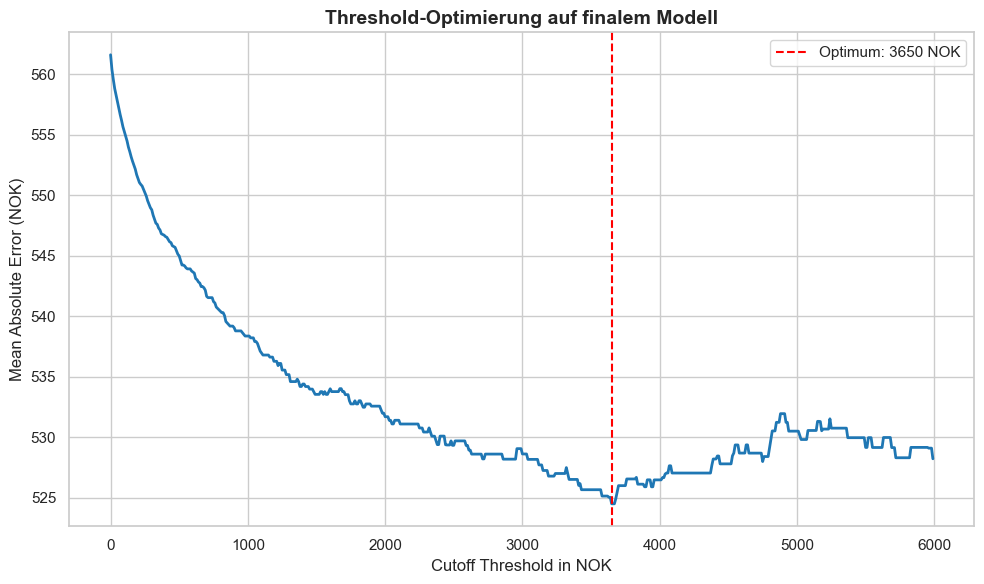

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

plt.plot(cutoff_df["Threshold"], cutoff_df["MAE"], color='#1f77b4', linewidth=2)
plt.axvline(x=best_cutoff['Threshold'], color='red', linestyle='--', label=f"Optimum: {best_cutoff['Threshold']:.0f} NOK")

plt.title('Threshold-Optimierung auf finalem Modell', fontsize=14, fontweight='bold')
plt.xlabel('Cutoff Threshold in NOK', fontsize=12)
plt.ylabel('Mean Absolute Error (NOK)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()